In [28]:
import os, sys
repo_root = os.path.abspath('..')
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from src.data_loader import get_returns
from src.var_historical import historical_var, historical_cvar
from src.var_parametric import parametric_var, parametric_cvar
from src.var_montecarlo import mc_var_normal, mc_var_student_t, mc_summary

pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
print("Imports OK")

Imports OK


In [29]:
TICKER = "NVDA"
data = get_returns(TICKER, "2020-01-01")
returns = data['log_return']
print(f"Sample: {len(data)} days")

Sample: 1611 days


In [30]:
def four_method_row(conf):
    hv = historical_var(returns, conf);  hc = historical_cvar(returns, conf)
    pv = parametric_var(returns, conf);  pc = parametric_cvar(returns, conf)
    nv, ncv = mc_var_normal(returns, conf)
    tv, tcv, df = mc_var_student_t(returns, conf)
    return {
        'Confidence': f"{int(conf*100)}%",
        'Historical_VaR': hv, 'Parametric_VaR': pv,
        'MC_Normal_VaR': nv,  'MC_t_VaR': tv,
        'Historical_CVaR': hc, 'MC_t_CVaR': tcv,
    }

table = pd.DataFrame([four_method_row(c) for c in (0.95, 0.99)])
print(table.to_string(index=False))

Confidence  Historical_VaR  Parametric_VaR  MC_Normal_VaR  MC_t_VaR  Historical_CVaR  MC_t_CVaR
       95%          0.0489          0.0517         0.0521    0.0483           0.0716     0.0704
       99%          0.0805          0.0740         0.0746    0.0825           0.1053     0.1098


Four methods, one truth

At 99% confidence:
- Historical (8.05%) is the empirical benchmark — what actually happened.
- Parametric and MC Normal (~7.4-7.5%) agree with each other and both
  UNDERSTATE risk — the normal distribution can't see NVDA's fat tails.
- MC Student-t (8.25%) recovers the tail, landing next to historical.

The fitted Student-t has df = 4.86 — well below the df -> infinity that would
make it normal. df < 5 signals heavy tails, consistent with Day 1's kurtosis
of 4.12.

The CVaR gap is even starker: MC-t expected shortfall (10.98%) matches
historical (10.53%), while normal methods say ~8.5%. Using a normal model
he  re would hide roughly 2 percentage points of tail risk.

Note the 95% reversal: MC-t VaR (4.83%) is LOWER than MC-Normal (5.21%).
Student-t puts mass in the center and far tails but less in the shoulders,
so the fat-tail effect only dominates in the deep (99%) tail.

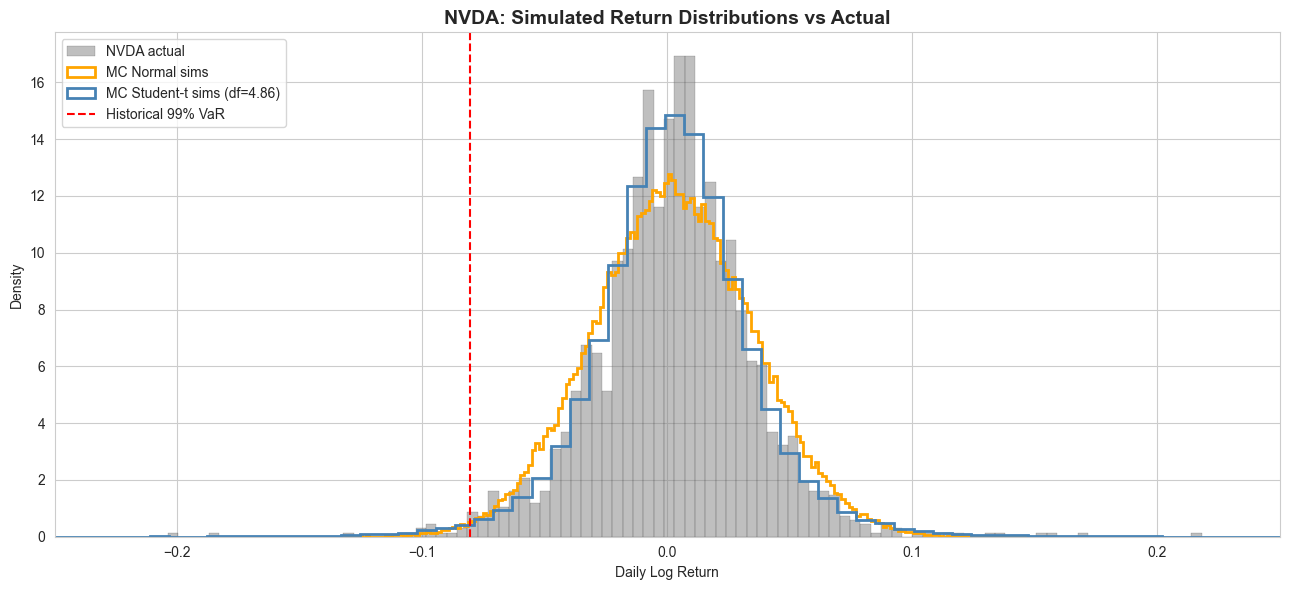

In [31]:
rng = np.random.default_rng(42)
mu, sigma = returns.mean(), returns.std()
df_t, loc_t, scale_t = stats.t.fit(returns)

sims_normal = rng.normal(mu, sigma, 100_000)
sims_t = stats.t.rvs(df_t, loc=loc_t, scale=scale_t, size=100_000, random_state=rng)

fig, ax = plt.subplots(figsize=(13, 6))
ax.hist(returns, bins=100, density=True, alpha=0.5, color='gray',
        label='NVDA actual', edgecolor='black', linewidth=0.2)
ax.hist(sims_normal, bins=200, density=True, histtype='step',
        color='orange', linewidth=2, label='MC Normal sims')
ax.hist(sims_t, bins=200, density=True, histtype='step',
        color='steelblue', linewidth=2, label=f'MC Student-t sims (df={df_t:.2f})')

ax.axvline(-historical_var(returns, 0.99), color='red', linestyle='--',
           linewidth=1.5, label='Historical 99% VaR')
ax.set_xlim(-0.25, 0.25)
ax.set_title('NVDA: Simulated Return Distributions vs Actual',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Daily Log Return'); ax.set_ylabel('Density')
ax.legend(loc='upper left', fontsize=10)
plt.tight_layout()
plt.savefig('../outputs/nvda_mc_distributions.png', dpi=120, bbox_inches='tight')
plt.show()

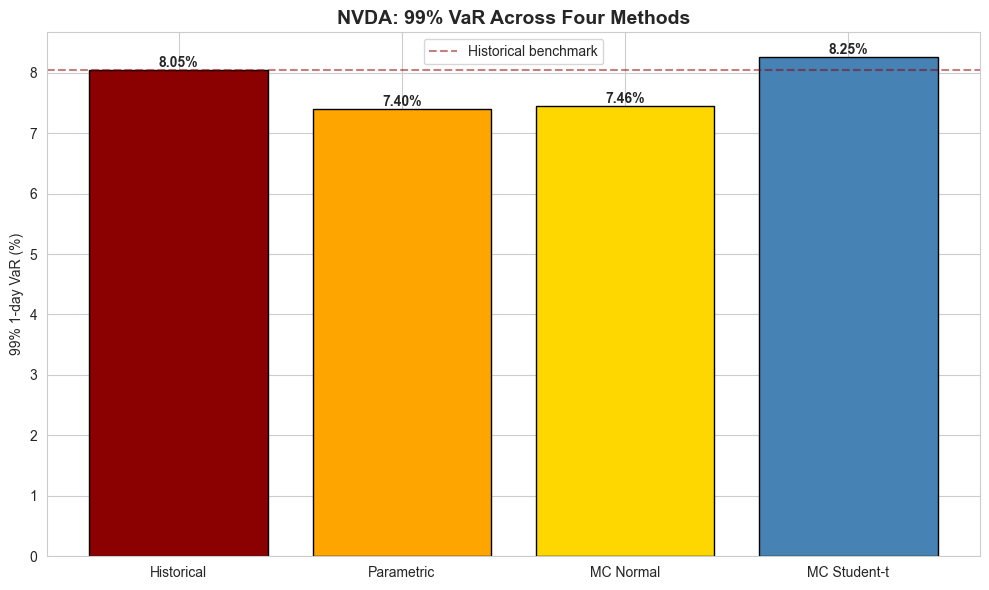

In [32]:
methods = ['Historical', 'Parametric', 'MC Normal', 'MC Student-t']
var99 = [historical_var(returns,0.99), parametric_var(returns,0.99),
         mc_var_normal(returns,0.99)[0], mc_var_student_t(returns,0.99)[0]]

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['darkred','orange','gold','steelblue']
bars = ax.bar(methods, [v*100 for v in var99], color=colors, edgecolor='black')
ax.axhline(historical_var(returns,0.99)*100, color='darkred',
           linestyle='--', alpha=0.5, label='Historical benchmark')
for bar, v in zip(bars, var99):
    ax.text(bar.get_x()+bar.get_width()/2, v*100+0.05, f'{v:.2%}',
            ha='center', fontsize=10, fontweight='bold')
ax.set_ylabel('99% 1-day VaR (%)')
ax.set_title('NVDA: 99% VaR Across Four Methods', fontsize=14, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('../outputs/nvda_var_methods_bar.png', dpi=120, bbox_inches='tight')
plt.show()

Key takeaways — Monte Carlo VaR

1. MC Normal validates the code — it matches closed-form parametric VaR
   (~7.4%), as it must. Two independent normal methods agreeing = no bug.
2. MC Student-t recovers the tail — 99% VaR 8.25%, CVaR 10.98%, both close
   to historical. Fat-tailed simulation captures what normal misses.
3. Fitted df = 4.86 quantifies NVDA's tail heaviness; df < 5 = seriously fat.
4. Normal methods hide ~2pp of 99% expected shortfall — material on any real
   position.
5. Method choice is confidence-dependent — fat tails dominate at 99%, not 95%.
6. Next (Week 2): extend to a multi-asset portfolio — covariance, correlated
   Monte Carlo draws (Cholesky), and component VaR.